Импорт библиотек

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import re
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [ ]:
Загрузка датасета и первичные проверки

In [8]:
dataset = pd.read_csv('Dataset.csv')

In [27]:
dataset.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [28]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [29]:
dataset.shape

(53043, 3)

Предобработка данных

In [9]:
#удаление дубликатов
initial_shape = dataset.shape[0]
dataset = dataset.drop_duplicates(subset=['statement'])
print(f"Удалено дубликатов: {initial_shape - dataset.shape[0]}")

Удалено дубликатов: 1969


Удаление NaN

In [10]:
initial_shape = dataset.shape[0]
dataset = dataset.dropna(subset=['statement', 'status'])
print(f"Удалено строк с NaN: {initial_shape - dataset.shape[0]}")

Удалено строк с NaN: 1


In [ ]:
Очистка текста (удаление лишних пробелов, приведение к нижнему регистру)

In [11]:
def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'\s+', ' ', text)
        text = text.lower()
        return text
    return ""

dataset['clean_statement'] = dataset['statement'].apply(clean_text)

In [33]:
#проверка
dataset.head()

,Unnamed: 0,statement,status,clean_statement
0,0,oh my gosh,Anxiety,oh my gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,"trouble sleeping, confused mind, restless hear..."
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"all wrong, back off dear, forward doubt. stay ..."
3,3,I've shifted my focus to something else but I'...,Anxiety,i've shifted my focus to something else but i'...
4,4,"I'm restless and restless, it's been a month n...",Anxiety,"i'm restless and restless, it's been a month n..."


Кодирование целевой переменной (Anxiety -> 0 Normal -> 3 и т.д.)

In [12]:
le = LabelEncoder()
dataset['label'] = le.fit_transform(dataset['status'])
print("СООТВЕТСТВИЕ КОДОВ СТАТУСАМ")
for i, status_name in enumerate(le.classes_):
    print(f"  {i} -> {status_name}")

СООТВЕТСТВИЕ КОДОВ СТАТУСАМ
  0 -> Anxiety
  1 -> Bipolar
  2 -> Depression
  3 -> Normal
  4 -> Personality disorder
  5 -> Stress
  6 -> Suicidal


Векторизация текста с помощью TF-IDF

In [43]:
vectorizer = TfidfVectorizer(max_features=2000,
                             stop_words='english',
                             ngram_range=(1, 2))

X = vectorizer.fit_transform(dataset['clean_statement']).toarray()
y = dataset['label'].values

print(f"Размер матрицы признаков X: {X.shape}")

Размер матрицы признаков X: (51073, 2000)


In [ ]:
Разделение на обучающую и тестовую выборки

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} примеров")
print(f"Тестовая выборка: {X_test.shape[0]} примеров")

Обучающая выборка: 40858 примеров
Тестовая выборка: 10215 примеров


ЛИНЕЙНАЯ РЕГРЕССИЯ

In [ ]:
Обучение модели ЛИНЕЙНОЙ РЕГРЕСИИ

In [66]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Модель обучена!")

Модель обучена!


In [ ]:
Предсказние и оценка

In [47]:
y_pred_continuous = model.predict(X_test) 

y_pred_class = (y_pred_continuous >= 0.5).astype(int)

mse = mean_squared_error(y_test, y_pred_continuous)
r2 = r2_score(y_test, y_pred_continuous)

accuracy = accuracy_score(y_test, y_pred_class)

print("\nРЕЗУЛЬТАТЫ")
print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"Точность (Accuracy) при пороге 0.5: {accuracy:.4f}")


РЕЗУЛЬТАТЫ
Среднеквадратичная ошибка (MSE): 2.0725
R² (коэффициент детерминации): 0.3492
Точность (Accuracy) при пороге 0.5: 0.0597


!!! Результаты крайне плохие. точность неверроятно низкая. 
!!! У нас стоит задача многокрассовой классификации (Anixiety, Normal, Depression и т.д.)
!!! Для данной задачи модель линейной регресии не подходит, и мы это доказали

In [ ]:
ЛОГИСТИЧЕСКАЯ МОДЕЛЬ

In [67]:
logreg = LogisticRegression(
    multi_class='ovr',
    max_iter=1000,
    C=1.0, 
    random_state=42,
    solver='lbfgs'
)

# обучение

logreg.fit(X_train, y_train)
print("Модель обучена!")

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Модель обучена!


Оценка качества модели и метрик

In [52]:
y_pred_logreg = logreg.predict(X_test)

y_pred_proba = logreg.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred_logreg)
precision_macro = precision_score(y_test, y_pred_logreg, average='macro')
recall_macro = recall_score(y_test, y_pred_logreg, average='macro')
f1_macro = f1_score(y_test, y_pred_logreg, average='macro')

print(f"Accuracy (точность): {accuracy:.4f}")
print(f"Precision (макро): {precision_macro:.4f}")
print(f"Recall (макро): {recall_macro:.4f}")
print(f"F1-score (макро): {f1_macro:.4f}")

Accuracy (точность): 0.7458
Precision (макро): 0.7762
Recall (макро): 0.6036
F1-score (макро): 0.6508


In [ ]:
Отчёт ко каждому классу

In [53]:
print(classification_report(y_test, y_pred_logreg, 
                          target_names=le.classes_))

                      precision    recall  f1-score   support

             Anxiety       0.81      0.73      0.77       723
             Bipolar       0.84      0.60      0.70       500
          Depression       0.68      0.71      0.69      3018
              Normal       0.82      0.96      0.88      3208
Personality disorder       0.91      0.29      0.44       179
              Stress       0.69      0.29      0.40       459
            Suicidal       0.67      0.65      0.66      2128

            accuracy                           0.75     10215
           macro avg       0.78      0.60      0.65     10215
        weighted avg       0.74      0.75      0.74     10215



Матрица ошибок

        Anxiety    Bipolar Depression     Normal Personality disorder     Stress   Suicidal
Anxiety           528         10         85         84          1          8          7
Bipolar            14        299        109         48          1         13         16
Depression         48         21       2136        234          0         15        564
Normal              9          0         53       3087          2         12         45
Personality disorder          3          4         71         32         52          8          9
Stress             44          9        138        103          1        131         33
Suicidal            2         11        546        181          0          3       1385


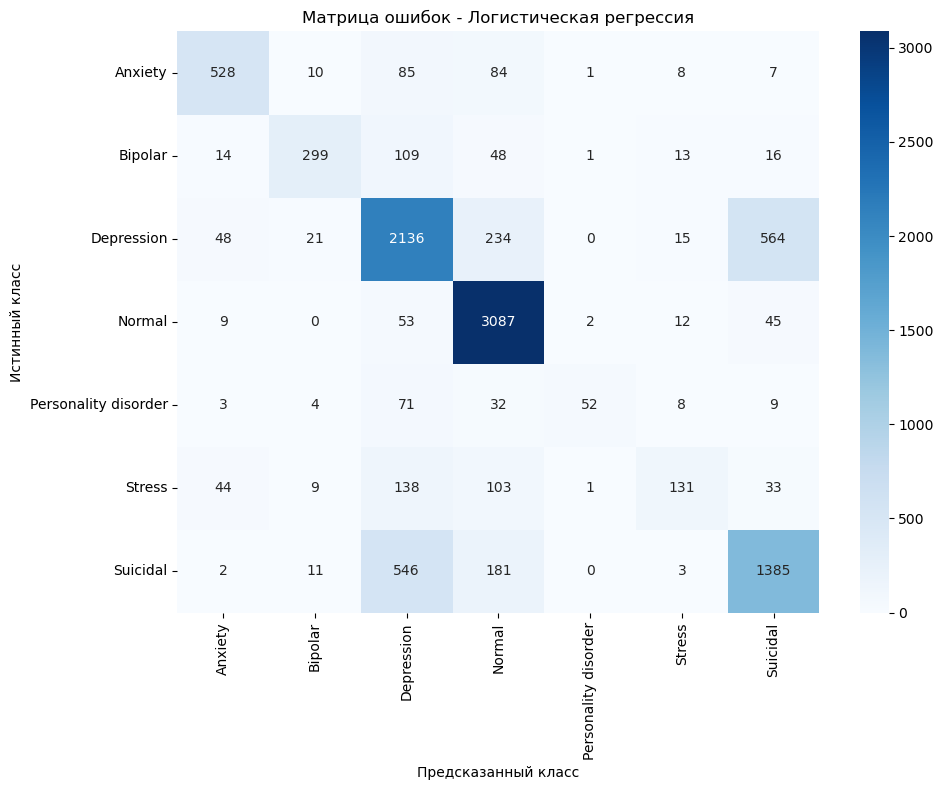

In [72]:
cm = confusion_matrix(y_test, y_pred_logreg)

print("     " + " ".join([f"{name:>10}" for name in le.classes_]))
for i, row in enumerate(cm):
    print(f"{le.classes_[i]:10} " + " ".join([f"{val:10d}" for val in row]))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Матрица ошибок - Логистическая регрессия')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

Предсказания на новом тексте

In [70]:
test_texts = [
    "I constantly worry and can't sleep, I'm haunted by fears",
    "I don't have the strength to get out of bed, life seems meaningless",
    "I want to end my life, I can't bear this pain anymore",
    "Today is a wonderful day, I'm happy and full of energy",
    "My mood changes dramatically: from euphoria to depression",
    "I'm overloaded with work and constantly under stress"
]

expected_classes = [
    "Anxiety",      
    "Depression", 
    "Suicidal",   
    "Normal",     
    "Bipolar",    
    "Stress"      
]

def predict_with_logreg(text, model, vectorizer, label_encoder, show_all_probs=True):
    
    cleaned_text = text.lower()
    
    text_vector = vectorizer.transform([cleaned_text])
    
    prediction_code = model.predict(text_vector)[0]
    prediction = label_encoder.inverse_transform([prediction_code])[0]
    
    probabilities = model.predict_proba(text_vector)[0]
    
    return prediction, probabilities

results = []

for i, text in enumerate(test_texts):
    print(f"   Текст: {text}")
    print(f"   Ожидаемый класс: {expected_classes[i]}")
    
    prediction, probabilities = predict_with_logreg(
        text, 
        logreg,
        vectorizer, 
        le, 
        show_all_probs=True
    )
    
    print(f"\n Предсказанный класс: {prediction}")
    print(f"Уверенность: {max(probabilities)*100:.2f}%")

   Текст: I constantly worry and can't sleep, I'm haunted by fears
   Ожидаемый класс: Anxiety

 Предсказанный класс: Anxiety
Уверенность: 50.50%
   Текст: I don't have the strength to get out of bed, life seems meaningless
   Ожидаемый класс: Depression

 Предсказанный класс: Normal
Уверенность: 80.86%
   Текст: I want to end my life, I can't bear this pain anymore
   Ожидаемый класс: Suicidal

 Предсказанный класс: Suicidal
Уверенность: 86.41%
   Текст: Today is a wonderful day, I'm happy and full of energy
   Ожидаемый класс: Normal

 Предсказанный класс: Normal
Уверенность: 71.59%
   Текст: My mood changes dramatically: from euphoria to depression
   Ожидаемый класс: Bipolar

 Предсказанный класс: Depression
Уверенность: 87.08%
   Текст: I'm overloaded with work and constantly under stress
   Ожидаемый класс: Stress

 Предсказанный класс: Stress
Уверенность: 76.38%


In [ ]:
Чётко заметна следующая закономерность: 
Чем больше в датасете информации, тем лучше модель распознаёт тот или иной класс
Лучше всего ей удаются Normal, Anxiety и Suicidal, так как у низ больше всего примеров в датасете

Наивный байесовский классификатор

1) Multinomial Naive Bayes

In [58]:
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
y_pred_proba_mnb = mnb.predict_proba(X_test)
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"   Accuracy: {accuracy_mnb:.4f}")

   Accuracy: 0.6752


2) Bernoulli Naive Bayes

In [59]:
bnb = BernoulliNB(alpha=1.0, binarize=0.0)
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print(f"   Accuracy: {accuracy_bnb:.4f}")

   Accuracy: 0.6214


3) Gaussian Naive Bayes

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"   Accuracy: {accuracy_gnb:.4f}")

   Accuracy: 0.5112


In [ ]:
Лучшая модель по точности

In [62]:
models_comparison = {
    'MultinomialNB': {'model': mnb, 'y_pred': y_pred_mnb, 'accuracy': accuracy_mnb},
    'BernoulliNB': {'model': bnb, 'y_pred': y_pred_bnb, 'accuracy': accuracy_bnb},
    'GaussianNB': {'model': gnb, 'y_pred': y_pred_gnb, 'accuracy': accuracy_gnb}
}

sorted_models = sorted(models_comparison.items(), key=lambda x: x[1]['accuracy'], reverse=True)

print("\nРейтинг моделей по accuracy:")
for i, (model_name, model_data) in enumerate(sorted_models, 1):
    print(f"   {i}. {model_name}: {model_data['accuracy']:.4f}")


Рейтинг моделей по accuracy:
   1. MultinomialNB: 0.6752
   2. BernoulliNB: 0.6214
   3. GaussianNB: 0.5112


In [63]:
best_model_name, best_model_data = sorted_models[0]
best_nb_model = best_model_data['model']
y_pred_best = best_model_data['y_pred']

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


📋 Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.81      0.63      0.71       723
             Bipolar       0.87      0.46      0.60       500
          Depression       0.53      0.75      0.63      3018
              Normal       0.81      0.83      0.82      3208
Personality disorder       1.00      0.10      0.18       179
              Stress       0.82      0.09      0.16       459
            Suicidal       0.69      0.58      0.63      2128

            accuracy                           0.68     10215
           macro avg       0.79      0.49      0.53     10215
        weighted avg       0.71      0.68      0.66     10215



Матрица ошибок

          Anxiety      Bipolar   Depression       Normal Personality disorder       Stress     Suicidal
Anxiety                  457            6          155          103            0            0            2
Bipolar                   10          231          205           44            0            5            5
Depression                41           20         2272          209            0            2          474
Normal                    16            1          472         2647            0            1           71
Personality disorder            1            2          121           31           18            1            5
Stress                    37            3          266          106            0           40            7
Suicidal                   5            4          759          128            0            0         1232


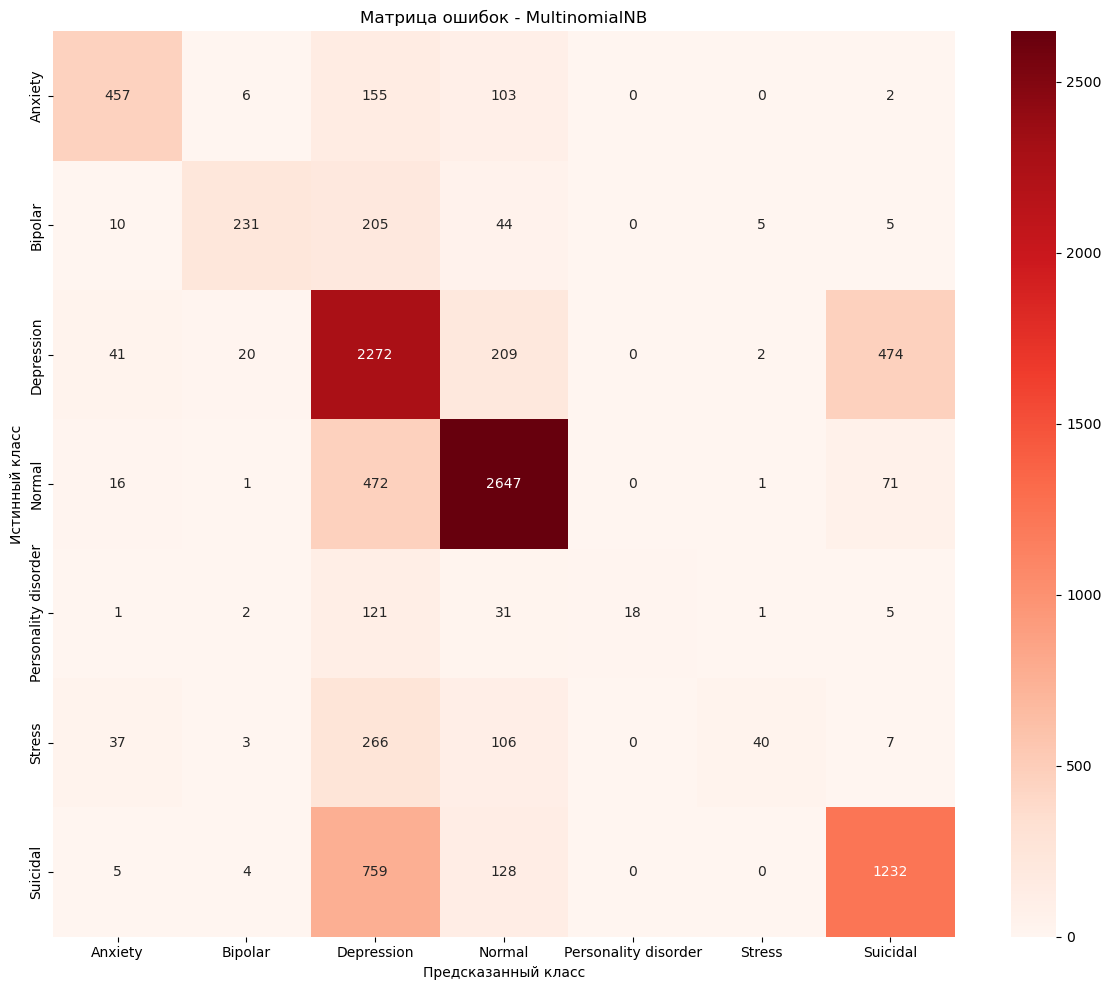

In [71]:
cm_nb = confusion_matrix(y_test, y_pred_best)

print("     " + " ".join([f"{name:>12}" for name in le.classes_]))
for i, row in enumerate(cm_nb):
    print(f"{le.classes_[i]:15} " + " ".join([f"{val:12d}" for val in row]))

plt.figure(figsize=(12, 10))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title(f'Матрица ошибок - {best_model_name}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

Предсказания на новом тексте

In [65]:
def predict_with_nb(text, model, vectorizer, label_encoder):
    """
    Предсказывает класс для текста с использованием Naive Bayes
    """
    if 'clean_text' in globals():
        cleaned_text = clean_text(text)
    else:
        cleaned_text = text.lower()
    
    text_vector = vectorizer.transform([cleaned_text])
    
    prediction_code = model.predict(text_vector)[0]
    prediction = label_encoder.inverse_transform([prediction_code])[0]
    
    probabilities = model.predict_proba(text_vector)[0]
    
    print(f"\nТекст: {text[:80]}...")
    print(f"Предсказание: {prediction}")
    print(f"Уверенность: {max(probabilities)*100:.2f}%")
    print("   Вероятности по классам:")
    for class_name, prob in zip(label_encoder.classes_, probabilities):
        if prob > 0.05:
            print(f"      {class_name}: {prob:.2%}")
    
    return prediction, probabilities

test_texts_nb = [
    "I constantly worry and can't sleep, I'm haunted by fears",
    "I don't have the strength to get out of bed, life seems meaningless",
    "I want to end my life, I can't bear this pain anymore",
    "Today is a wonderful day, I'm happy and full of energy",
    "My mood changes dramatically: from euphoria to depression",
    "I'm overloaded with work and constantly under stress"
]


for text in test_texts_nb:
    predict_with_nb(text, best_nb_model, vectorizer, le)


Текст: I constantly worry and can't sleep, I'm haunted by fears...
Предсказание: Anxiety
Уверенность: 52.89%
   Вероятности по классам:
      Anxiety: 52.89%
      Depression: 13.60%
      Normal: 9.04%
      Stress: 9.43%
      Suicidal: 9.00%

Текст: I don't have the strength to get out of bed, life seems meaningless...
Предсказание: Depression
Уверенность: 51.73%
   Вероятности по классам:
      Depression: 51.73%
      Normal: 19.48%
      Suicidal: 16.32%

Текст: I want to end my life, I can't bear this pain anymore...
Предсказание: Suicidal
Уверенность: 77.17%
   Вероятности по классам:
      Depression: 19.58%
      Suicidal: 77.17%

Текст: Today is a wonderful day, I'm happy and full of energy...
Предсказание: Normal
Уверенность: 45.47%
   Вероятности по классам:
      Bipolar: 5.19%
      Depression: 30.00%
      Normal: 45.47%
      Suicidal: 15.09%

Текст: My mood changes dramatically: from euphoria to depression...
Предсказание: Depression
Уверенность: 45.63%
   Вероятност